## **Problem Definition**

    EV Car Price Prediction.

    The electric vehicle (EV) market is growing rapidly, making accurate price estimation is critical 
    for buyers, sellers, and manufacturers. The goal is to build a machine learning model that predicts
    the price of an electric vehicle based on its technical specifications and market characteristics -
    helping stakeholders make informed pricing and purchasing decisions.

## **Importing Necessary Libraries**

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

## **Dataset Overview**

In [3]:
df = pd.read_csv("../data/raw/ev_market_2026.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  2000 non-null   object 
 1   model                  2000 non-null   object 
 2   year                   2000 non-null   int64  
 3   variant                2000 non-null   object 
 4   price_usd              2000 non-null   float64
 5   battery_capacity_kwh   2000 non-null   float64
 6   range_miles            2000 non-null   float64
 7   charging_speed_kw      2000 non-null   float64
 8   acceleration_0_60_mph  2000 non-null   float64
 9   top_speed_mph          2000 non-null   float64
 10  horsepower             2000 non-null   float64
 11  torque_nm              2000 non-null   float64
 12  drive_type             2000 non-null   object 
 13  seating_capacity       2000 non-null   int64  
 14  body_type              2000 non-null   object 
 15  carg

In [4]:
df.sample(10)

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
1104,Volvo,XC90 Recharge,2022,Performance,74428.14,86.1,316.0,151.1,3.78,191.0,...,Truck,74.1,2794.0,5,2,Sweden,Premium,3031,3.51,3
1779,Mercedes,EQS,2023,Premium,111693.41,44.9,154.0,66.0,6.74,144.0,...,Hatchback,25.7,1500.0,4,1,Germany,Luxury,72096,3.64,6
243,Volkswagen,ID. Aero,2024,Long Range,59514.00,103.6,337.0,124.5,4.16,183.0,...,SUV,68.7,1974.0,4,2,Germany,Mid-range,230145,3.70,3
356,Tesla,Model 3,2025,Base,42979.12,62.8,229.0,275.3,7.90,133.0,...,SUV,51.8,1730.0,4,2,US,Mid-range,207769,3.71,5
1491,Volkswagen,ID.5,2021,Long Range,44741.31,93.3,312.0,57.6,4.33,186.0,...,Sedan,24.9,1689.0,5,2,Germany,Mid-range,254746,3.41,4
1605,Hyundai,Ioniq,2022,Base,28093.63,47.2,167.0,85.3,7.79,139.0,...,Van,68.5,1572.0,3,0,South Korea,Budget,119899,3.25,4
816,Kia,Niro EV,2024,Performance,81763.20,89.6,319.0,232.9,3.70,188.0,...,Coupe,25.0,1629.0,4,0,South Korea,Premium,93663,3.44,3
906,Ford,Mustang Mach-E,2024,Premium,62057.63,57.6,207.0,109.6,6.33,150.0,...,Van,69.8,1502.0,4,0,US,Mid-range,65997,3.42,3
1772,Audi,Q6 e-tron,2025,Standard,97077.65,52.8,197.0,133.8,7.59,132.0,...,Hatchback,33.6,1677.0,5,2,Germany,Premium,69050,3.19,6
1571,Tesla,Cybertruck,2024,Standard,125176.94,68.4,258.0,217.3,6.57,154.0,...,Truck,56.6,2263.0,5,2,US,Luxury,162760,3.82,5


In [5]:
df.describe()

,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,seating_capacity,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,annual_sales_units,customer_rating,warranty_years
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2024.028500,78873.907150,74.662800,261.825500,155.206300,5.630635,164.884500,665.744000,601.311500,5.747000,46.105850,1886.164500,4.377000,1.124500,129653.592000,3.572045,4.579000
std,1.410561,35296.621782,20.082879,71.028238,80.982301,1.417733,20.781244,267.124838,238.706686,1.045245,19.850264,383.772906,0.661127,0.919469,105775.154465,0.270398,1.218812
min,2020.000000,16394.330000,40.000000,150.000000,50.000000,2.500000,118.000000,150.000000,200.000000,2.000000,15.000000,1500.000000,3.000000,0.000000,656.000000,3.000000,3.000000
25%,2023.000000,52325.920000,58.475000,204.000000,90.975000,4.620000,148.000000,442.750000,391.750000,5.000000,28.175000,1570.000000,4.000000,0.000000,44296.500000,3.380000,4.000000
50%,2024.000000,73013.015000,75.100000,261.000000,132.100000,5.670000,165.000000,683.000000,615.500000,5.000000,41.250000,1740.500000,4.000000,1.000000,111188.000000,3.560000,4.000000
75%,2025.000000,99780.157500,87.550000,310.000000,217.300000,6.770000,181.000000,939.250000,845.000000,7.000000,64.700000,2149.500000,5.000000,2.000000,202496.750000,3.750000,5.000000
max,2026.000000,269775.200000,119.900000,447.000000,349.900000,8.000000,200.000000,1000.000000,988.000000,7.000000,80.000000,3000.000000,5.000000,3.000000,499717.000000,4.510000,8.000000


In [6]:
df.nunique()

brand                      20
model                      76
year                        7
variant                     5
price_usd                2000
battery_capacity_kwh      703
range_miles               281
charging_speed_kw        1331
acceleration_0_60_mph     521
top_speed_mph              82
horsepower                694
torque_nm                 687
drive_type                  3
seating_capacity            4
body_type                   6
cargo_volume_cubic_ft     589
weight_kg                 870
safety_rating               3
autopilot_level             4
country_of_origin           6
market_segment              4
annual_sales_units       1997
customer_rating           137
warranty_years              6
dtype: int64

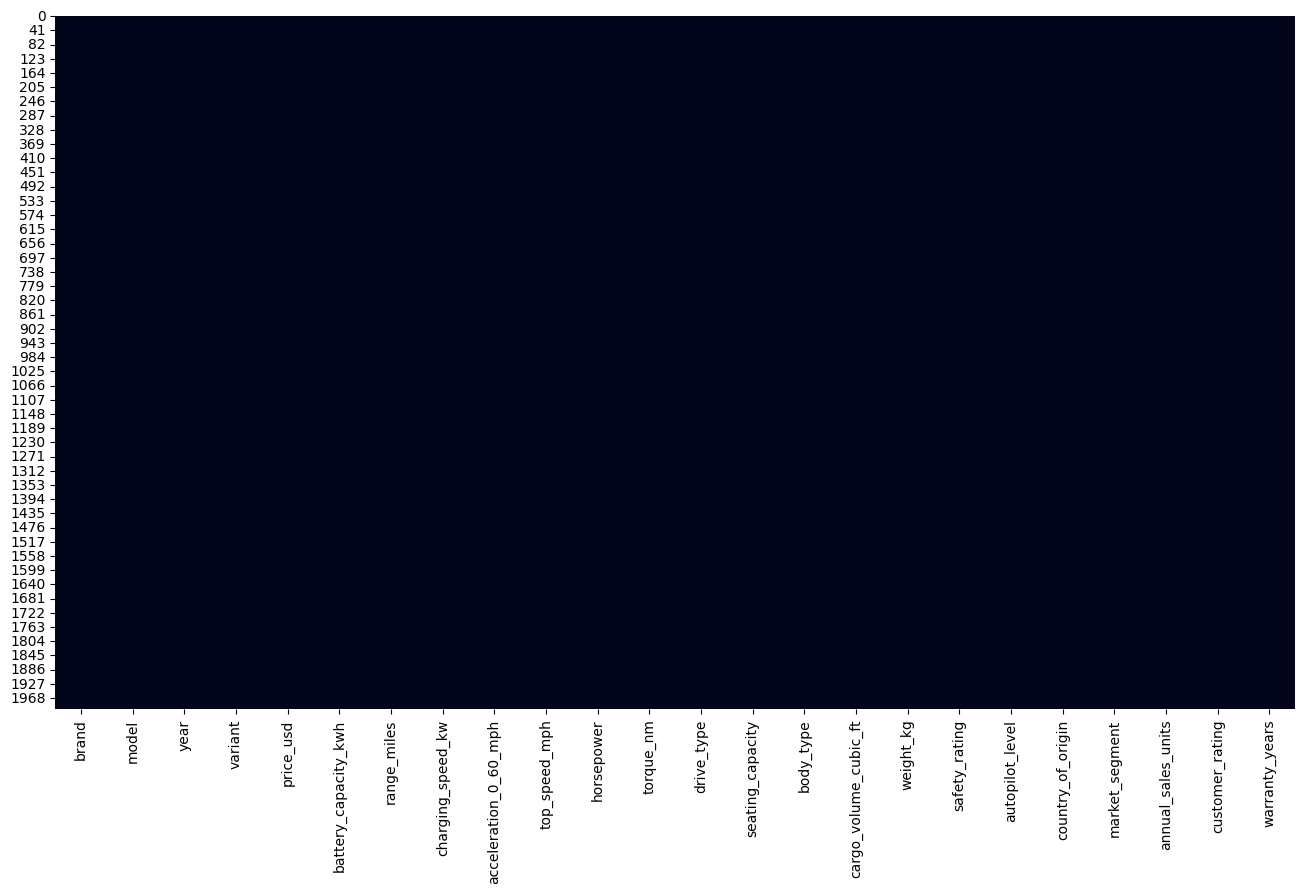

In [7]:
# visualize null values

plt.figure(figsize=(16,9))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

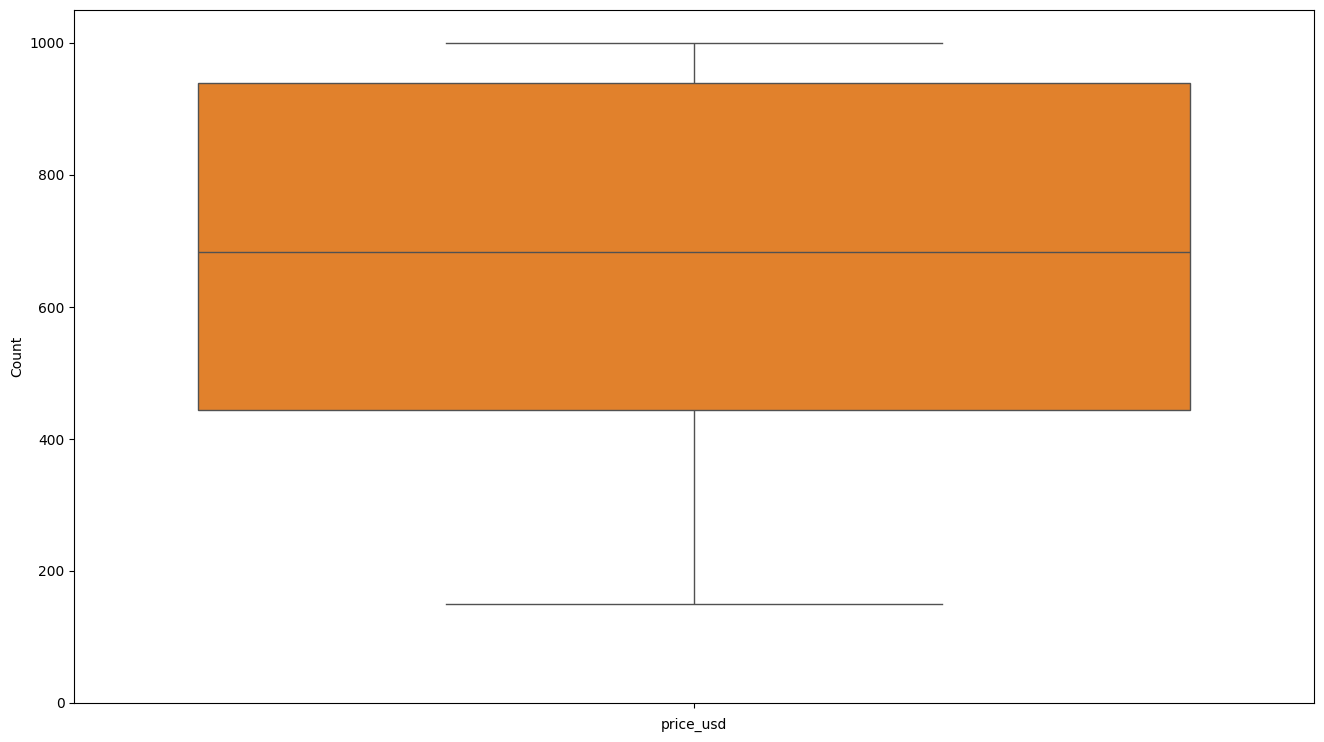

In [8]:
# Distributions

plt.figure(figsize=(16,9))
sns.histplot(df["price_usd"], kde=True)
sns.boxplot(df["horsepower"])
plt.show()

<Figure size 1600x1200 with 0 Axes>

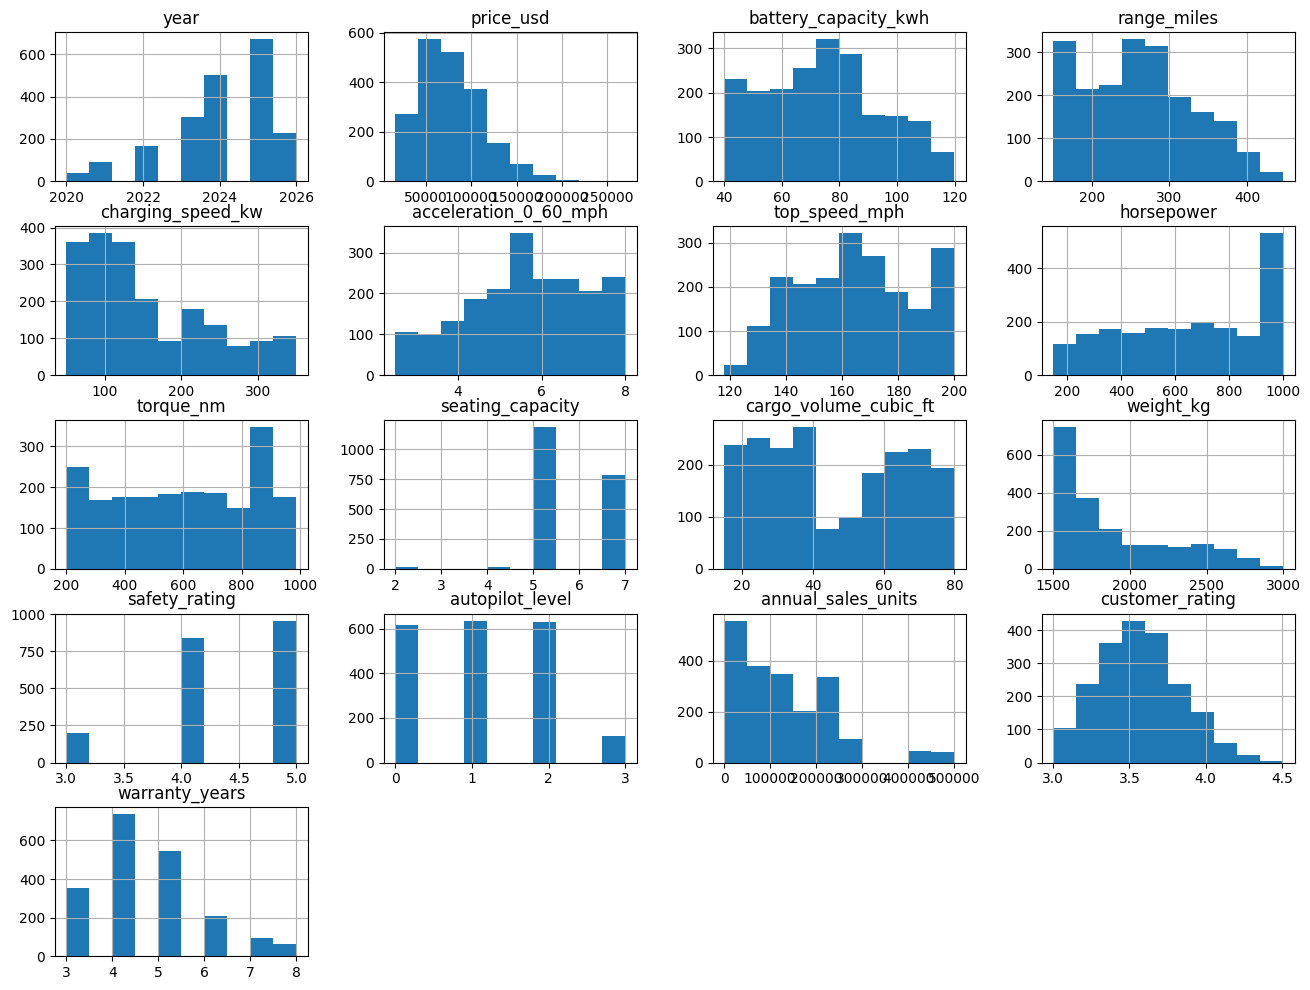

In [9]:
plt.figure(figsize=(16,12))
df.hist(figsize=(16,12))
plt.show()

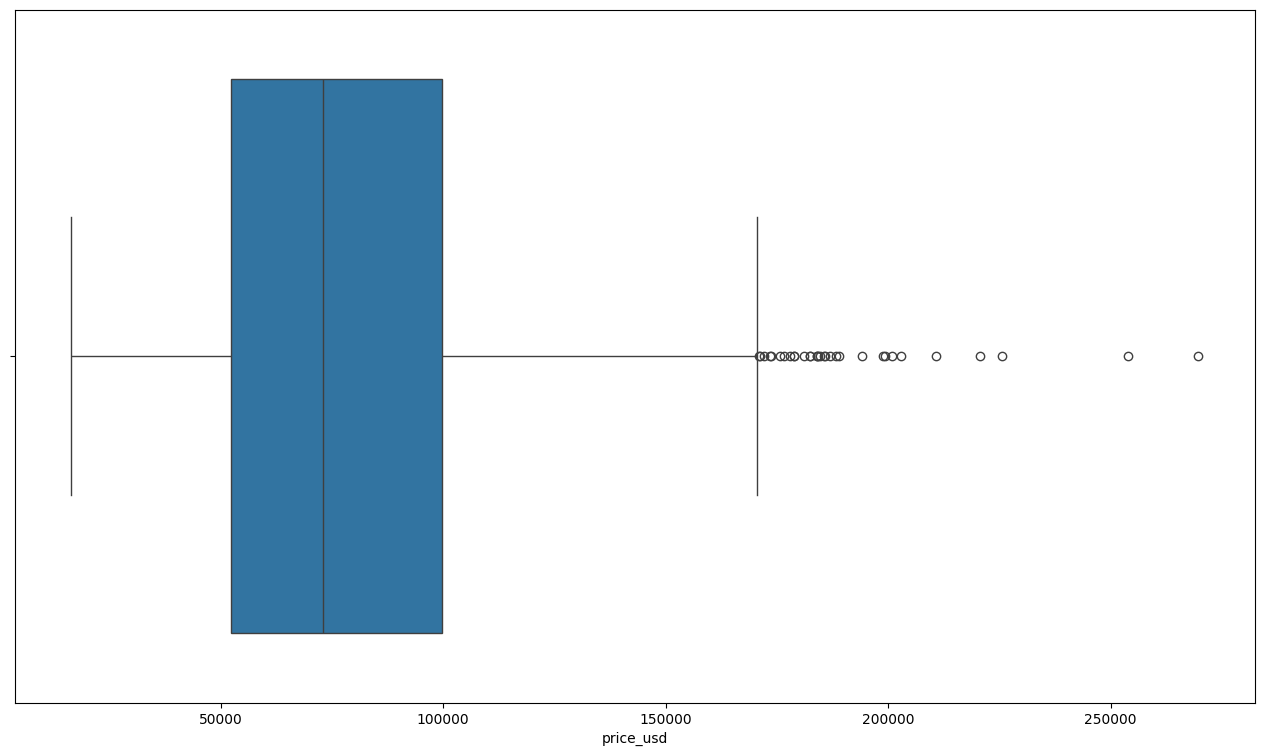

In [10]:
# Outliers 
plt.figure(figsize=(16,9))
sns.boxplot(data=df, x="price_usd")
plt.show()

<Axes: xlabel='body_type', ylabel='count'>

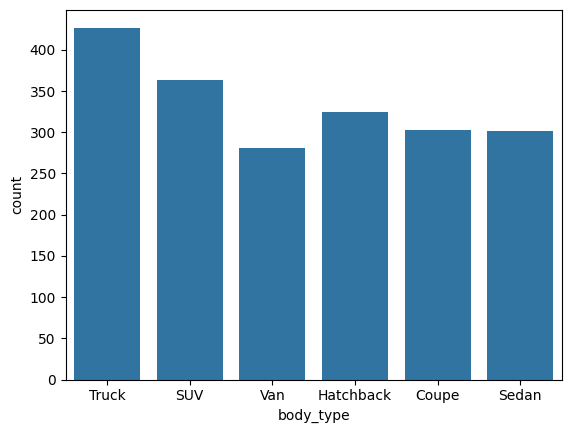

In [11]:
sns.countplot(data=df, x="body_type")

<Axes: xlabel='market_segment', ylabel='price_usd'>

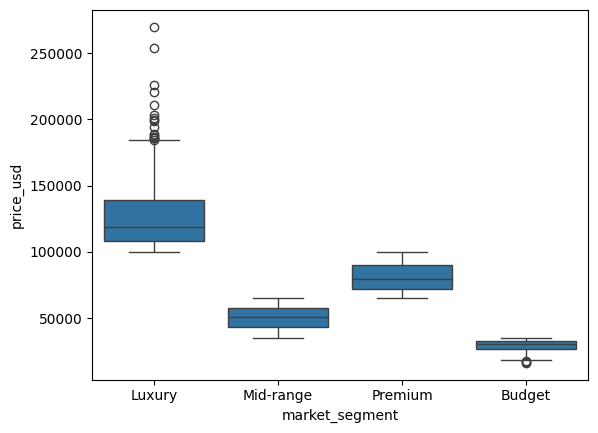

In [12]:
sns.boxplot(data=df, x="market_segment", y="price_usd")


<Axes: xlabel='brand', ylabel='price_usd'>

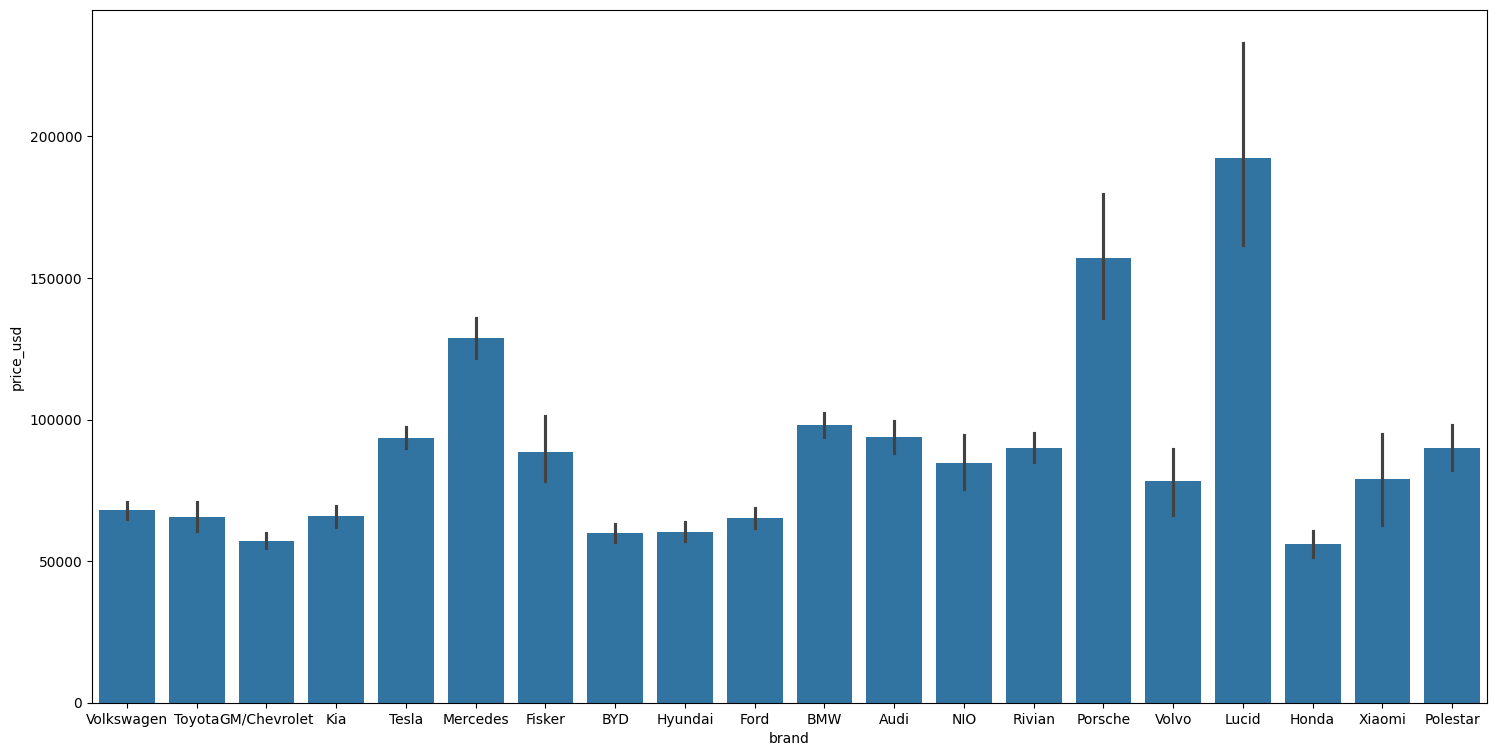

In [13]:
plt.figure(figsize=(18,9))
sns.barplot(data=df, x="brand", y="price_usd")

<Axes: xlabel='price_usd', ylabel='Count'>

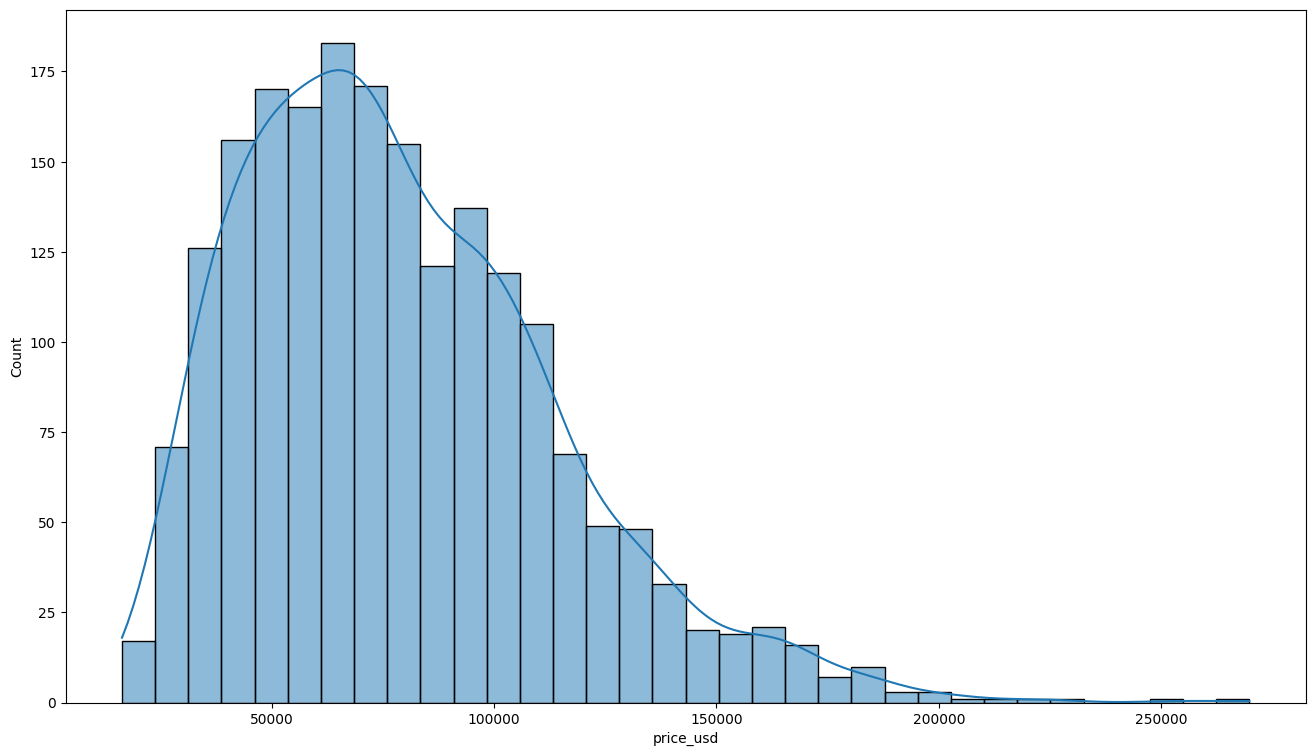

In [14]:
plt.figure(figsize=(16,9))
sns.histplot(df["price_usd"], kde=True)

## **Data Preprocessing**

In [15]:
# Handling missing values
df.isnull().sum()

brand                    0
model                    0
year                     0
variant                  0
price_usd                0
battery_capacity_kwh     0
range_miles              0
charging_speed_kw        0
acceleration_0_60_mph    0
top_speed_mph            0
horsepower               0
torque_nm                0
drive_type               0
seating_capacity         0
body_type                0
cargo_volume_cubic_ft    0
weight_kg                0
safety_rating            0
autopilot_level          0
country_of_origin        0
market_segment           0
annual_sales_units       0
customer_rating          0
warranty_years           0
dtype: int64

In [16]:
df.duplicated().sum()

0

In [17]:
df.sample(5)

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
1433,BMW,i4,2024,Base,47596.94,81.1,287.0,123.0,7.53,135.0,...,Sedan,15.4,1577.0,5,1,Germany,Mid-range,22877,3.56,7
1573,Mercedes,GLE EV,2024,Premium,134953.72,64.8,248.0,76.7,5.51,167.0,...,Van,61.4,1736.0,5,1,Germany,Luxury,76804,3.93,6
1506,Kia,EV6,2023,Long Range,68881.26,85.2,297.0,97.4,4.60,172.0,...,SUV,36.4,1755.0,4,0,South Korea,Premium,85490,3.48,4
52,NIO,ET6,2025,Performance,60624.73,82.4,278.0,174.8,2.63,200.0,...,SUV,48.0,2138.0,4,0,China,Mid-range,8857,3.49,4
1624,Tesla,Model X,2025,Base,95625.90,64.1,229.0,299.1,7.66,138.0,...,Coupe,21.1,1896.0,5,2,US,Premium,233990,3.63,5


In [18]:
# Encoding
# Every "object" column needs to be encoded with a unique type of encoding that best fits for them.

object_columns = df.select_dtypes(include="object").columns.to_list()
object_columns

['brand',
 'model',
 'variant',
 'drive_type',
 'body_type',
 'country_of_origin',
 'market_segment']

In [19]:
n_unique_counts = []
for col in object_columns:
    n_unique_counts.append(df[col].nunique())

n_unique_counts

[20, 76, 5, 3, 6, 6, 4]

In [20]:
encoder = LabelEncoder()

df["brand"] = encoder.fit_transform(df["brand"])
df["model"] = encoder.fit_transform(df["model"])
df["drive_type"] = encoder.fit_transform(df["drive_type"])
df["body_type"] = encoder.fit_transform(df["body_type"])
df["country_of_origin"] = encoder.fit_transform(df["country_of_origin"])


In [21]:
df['variant'].value_counts()

variant_mapping = {
    "Base" : 0,
    "Long Range" : 1,
    "Standard" : 2,
    "Premium" : 3,
    "Performance" : 4
}

df["variant"] = df['variant'].map(variant_mapping)


market_segment_mapping = {
    "Budget" : 0,
    "Mid-range" : 1,
    "Luxury" : 2, 
    "Premium" : 3
}

df["market_segment"] = df["market_segment"].map(market_segment_mapping)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  2000 non-null   int32  
 1   model                  2000 non-null   int32  
 2   year                   2000 non-null   int64  
 3   variant                2000 non-null   int64  
 4   price_usd              2000 non-null   float64
 5   battery_capacity_kwh   2000 non-null   float64
 6   range_miles            2000 non-null   float64
 7   charging_speed_kw      2000 non-null   float64
 8   acceleration_0_60_mph  2000 non-null   float64
 9   top_speed_mph          2000 non-null   float64
 10  horsepower             2000 non-null   float64
 11  torque_nm              2000 non-null   float64
 12  drive_type             2000 non-null   int32  
 13  seating_capacity       2000 non-null   int64  
 14  body_type              2000 non-null   int32  
 15  carg

## **Saving Preprocessed Data**

In [23]:
def save_dataframe(df, folder, filename):
    os.makedirs(folder, exist_ok=True)
    path = os.path.join(folder, filename)
    df.to_csv(path, index=False)
    print(f"saved to: {path}")

save_dataframe(df, "../data/preprocessed", "encoded_df.csv")

saved to: ../data/preprocessed\encoded_df.csv


In [24]:
df.sample()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
143,2,10,2024,3,89340.39,64.6,223.0,111.7,7.58,132.0,...,5,67.3,1633.0,5,2,0,3,229760,3.35,4


## **Model Selection**

### **Linear Regression**

In [25]:
# Linear Regression 

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

x = df.drop("price_usd", axis=1)
y = df["price_usd"]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

model_1 = LinearRegression()
model_1.fit(x_train, y_train)

y_pred = model_1.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

MAE:  11826.1591
MSE:  276979855.7877
RMSE: 16642.7118
R2:   0.7571


In [26]:
# K-fold cross validation

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_1, x,y,cv=kf, scoring="r2")
print(scores.mean())

from sklearn.metrics import make_scorer

mae=make_scorer(mean_absolute_error,greater_is_better=False)
scores=cross_val_score(model_1,x,y,cv=kf,scoring=mae)
print(-scores)

0.7805358228519068
[11826.15910771 11884.02511533 12862.51991845 12645.68750449
 11065.24580984]


### **Ridge Regression**

In [27]:
# Ridge Regression 

from sklearn.linear_model import Ridge

model_2 = Ridge()
model_2.fit(x_train, y_train)

y_pred = model_2.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")



MAE:  11821.8923
MSE:  276752143.0677
RMSE: 16635.8692
R2:   0.7573


In [28]:
# K-fold cross validation

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_2, x,y,cv=kf, scoring="r2")
print(scores.mean())

from sklearn.metrics import make_scorer

mae=make_scorer(mean_absolute_error,greater_is_better=False)
scores=cross_val_score(model_2,x,y,cv=kf,scoring=mae)
print(-scores)

0.7805424922599545
[11821.89230049 11884.5274217  12865.01046652 12642.97598477
 11066.83592035]


### **Lasso Regression**

In [29]:
from sklearn.linear_model import Lasso

model_3 = Lasso()
model_3.fit(x_train, y_train)

y_pred = model_3.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")



MAE:  11825.3911
MSE:  276950207.6494
RMSE: 16641.8210
R2:   0.7571


In [30]:
# K-fold cross validation

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_3, x,y,cv=kf, scoring="r2")
print(scores.mean())

from sklearn.metrics import make_scorer

mae=make_scorer(mean_absolute_error,greater_is_better=False)
scores=cross_val_score(model_3,x,y,cv=kf,scoring=mae)
print(-scores)

0.7805416144272488
[11825.3911149  11883.60381482 12862.68005037 12645.22799578
 11065.29199322]


### **Decision Tree Regression**


In [31]:
from sklearn.tree import DecisionTreeRegressor

model_4 = DecisionTreeRegressor()
model_4.fit(x_train, y_train)

y_pred = model_4.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.2f}")

print(f"{mae:.2f}, {mse:.2f}, {rmse:.2f}, {r2:.2f}")

MAE:  5106.30
MSE:  68981745.96
RMSE: 8305.53
R2:   0.94
5106.30, 68981745.96, 8305.53, 0.94


In [32]:
# K-fold cross validation

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_4, x,y,cv=kf, scoring="r2")
print(scores.mean())

from sklearn.metrics import make_scorer

mae=make_scorer(mean_absolute_error,greater_is_better=False)
scores=cross_val_score(model_4,x,y,cv=kf,scoring=mae)
print(-scores)

0.9140860801736288
[5173.504575 5996.3397   6083.588375 5356.032425 5364.353075]


### **Random Forest Regressor**

In [33]:
from sklearn.ensemble import RandomForestRegressor

model_5 = RandomForestRegressor(n_estimators=100)
model_5.fit(x_train, y_train)

y_pred = model_5.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.2f}")

print(f"{mae:.2f}, {mse:.2f}, {rmse:.2f}, {r2:.2f}")


MAE:  4762.79
MSE:  54728353.58
RMSE: 7397.86
R2:   0.95
4762.79, 54728353.58, 7397.86, 0.95


In [34]:
# K-fold cross validation

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_5, x,y,cv=kf, scoring="r2")
print(scores.mean())

from sklearn.metrics import make_scorer

mae=make_scorer(mean_absolute_error,greater_is_better=False)
scores=cross_val_score(model_5,x,y,cv=kf,scoring=mae)
print(-scores)

0.9497815498338389
[4826.1598255  4901.6146585  5437.9917435  4903.65036925 4169.2179065 ]


### **GradientBoosting**

In [35]:
from sklearn.ensemble import GradientBoostingRegressor

model_6 = GradientBoostingRegressor(n_estimators=100)
model_6.fit(x_train, y_train)

y_pred = model_6.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.2f}")

print(f"{mae:.2f}, {mse:.2f}, {rmse:.2f}, {r2:.2f}")


MAE:  6004.97
MSE:  78493289.18
RMSE: 8859.64
R2:   0.93
6004.97, 78493289.18, 8859.64, 0.93


In [36]:
# K-fold cross validation

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_6, x,y,cv=kf, scoring="r2")
print(scores.mean())

from sklearn.metrics import make_scorer

mae=make_scorer(mean_absolute_error,greater_is_better=False)
scores=cross_val_score(model_6,x,y,cv=kf,scoring=mae)
print(-scores)

0.9395373982312802
[5987.54992932 5946.29236675 5946.95386775 5994.28544722 4817.75877692]


### **XGBoost**

In [37]:
import xgboost as xgb

model_7 = xgb.XGBRegressor(n_estimators=100)
model_7.fit(x_train, y_train)

y_pred = model_7.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.2f}")

print(f"{mae:.2f}, {mse:.2f}, {rmse:.2f}, {r2:.2f}")

MAE:  5068.37
MSE:  60554925.34
RMSE: 7781.70
R2:   0.95
5068.37, 60554925.34, 7781.70, 0.95


In [39]:
# K-fold cross validation

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_7, x,y,cv=kf, scoring="r2")
print(scores.mean())

from sklearn.metrics import make_scorer

mae=make_scorer(mean_absolute_error,greater_is_better=False)
scores=cross_val_score(model_7,x,y,cv=kf,scoring=mae)
print(-scores)

0.9473543603875425
[5068.3670791  5000.44958906 5312.20085547 5131.50686484 4080.84413555]


### **LightGBM**

In [41]:
import sys
!{sys.executable} -m pip install lightgbm

  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/5e/23/f8b28ca248bb629b9e08f877dd2965d1994e1674a03d67cd10c5246da248/lightgbm-4.6.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.5 MB 393.8 kB/s eta 0:00:04
   -- ------------------------------------- 0.1/1.5 MB 655.4 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.5 MB 774.0 kB/s eta 0:00:02
   ------ --------------------------------- 0.2/1.5 MB 1.1 MB/s eta 0:00:02
   ------- -------------------------------- 0.3/1.5 MB 1.0 MB/s eta 0:00:02
   ------------- -------------------------- 0.5/1.5 MB 1.6 MB/s eta 0:00:01
   ----------------- ---------------------- 0.6/1.5 MB 1.7 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.5 MB 2.4 MB/s eta 0:00:01
   ---------------------------------- ---

In [45]:
import lightgbm as lgb

model_8 = lgb.LGBMRegressor(n_estimators=100, force_col_wise=True)
model_8.fit(x_train, y_train)

y_pred = model_8.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.2f}")

print(f"{mae:.2f}, {mse:.2f}, {rmse:.2f}, {r2:.2f}")

[LightGBM] [Info] Total Bins 2616
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 23
[LightGBM] [Info] Start training from score 79099.065043
MAE:  4991.62
MSE:  63207625.34
RMSE: 7950.32
R2:   0.94
4991.62, 63207625.34, 7950.32, 0.94


In [46]:
# K-fold cross validation

from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model_8, x,y,cv=kf, scoring="r2")
print(scores.mean())

from sklearn.metrics import make_scorer

mae=make_scorer(mean_absolute_error,greater_is_better=False)
scores=cross_val_score(model_7,x,y,cv=kf,scoring=mae)
print(-scores)

[LightGBM] [Info] Total Bins 2616
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 23
[LightGBM] [Info] Start training from score 79099.065043
[LightGBM] [Info] Total Bins 2611
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 23
[LightGBM] [Info] Start training from score 78314.494951
[LightGBM] [Info] Total Bins 2608
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 23
[LightGBM] [Info] Start training from score 78760.152515
[LightGBM] [Info] Total Bins 2610
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 23
[LightGBM] [Info] Start training from score 79001.366458
[LightGBM] [Info] Total Bins 2614
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 23
[LightGBM] [Info] Start training from score 79194.456947
0.9482422712282386
[LightGBM] [Info] Total Bins 2616
[LightGBM] [Info] Number of data

### **SVR**

In [47]:
from sklearn.svm import SVR

model_9 = SVR()
model_9.fit(x_train, y_train)

y_pred = model_9.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.2f}")

print(f"{mae:.2f}, {mse:.2f}, {rmse:.2f}, {r2:.2f}")

MAE:  26545.78
MSE:  1161112811.56
RMSE: 34075.11
R2:   -0.02
26545.78, 1161112811.56, 34075.11, -0.02


## **Comparison**

In [52]:
from tabulate import tabulate

columns = ["Algorithm", "Mean Absolute Error", "Mean Squared Error", "Root Mean Squared Error", "R2_score"]

results = [["Linear Regression", 11826.1591, 276979855.7877, 16642.7118, 0.7571],
           ["Ridge Regression", 11821.8923, 276752143.0677, 16635.8692, 0.7573],
           ["Lasso Regression", 11825.3911, 276950207.6494, 16641.8210, 0.7571],
           ["Decision Tree Regressor", 5349.1, 79359968.94, 8908.42, 0.93],
           ["Random Forest Regressor", 4710.80, 52504306.91, 7245.99, 0.95],
           ["Gradient Boosting Regressor", 6008.04, 80303579.78, 8961.23, 0.93],
           ["XGBoost", 5068.37, 60554925.34, 7781.70, 0.95],
           ["LightGBM", 4991.62, 63207625.34, 7950.32, 0.94],
           ["Support Vector Regressor", 26545.78, 1161112811.56, 34075.11, -0.02]]

table = tabulate(results, headers = columns, tablefmt = 'grid', floatfmt='.2f')
print(table)

+-----------------------------+-----------------------+----------------------+---------------------------+------------+
| Algorithm                   |   Mean Absolute Error |   Mean Squared Error |   Root Mean Squared Error |   R2_score |
+=============================+=======================+======================+===========================+============+
| Linear Regression           |              11826.16 |         276979855.79 |                  16642.71 |       0.76 |
+-----------------------------+-----------------------+----------------------+---------------------------+------------+
| Ridge Regression            |              11821.89 |         276752143.07 |                  16635.87 |       0.76 |
+-----------------------------+-----------------------+----------------------+---------------------------+------------+
| Lasso Regression            |              11825.39 |         276950207.65 |                  16641.82 |       0.76 |
+-----------------------------+---------

### **Saving the best model which is Random Forest Regressor in this case**

In [53]:
# Saving the best model

from joblib import dump, load

# saving model to file

dump(model_5, "model_joblib")

['model_joblib']